In [2]:
# @title { vertical-output: true}

import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !pip install numpy matplotlib myplotlib sympy --quiet

In [3]:
# @title { vertical-output: true}

import numpy as np
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from myplotlib import register
import myplotlib.plots as myplt
import sympy as sp

register()

plt.style.use("guttenberg.light")

In [4]:
# @title { vertical-output: true}

# Figure parameters


class Parameters:
    class Common:
        C0 = "#3e6fb5"
        C1 = "#b2252a"
        C2 = "#6f8f5e"

    class Fig1:
        r0 = 1
        r = 1.2
        R = 5


# Common functions


def xmark(ax, x, y, size, **kwargs):
    ax.plot(
        [x - size, x + size],
        [y - size, y + size],
        **kwargs,
    )
    ax.plot(
        [x - size, x + size],
        [y + size, y - size],
        **kwargs,
    )

# Орбитальные парадоксы

Вывод искусственных спутников на орбиту вокруг Земли -- очень энергозатратное мероприятие. К примеру, в среднем, на вывод 1 кг груза на низкую околоземную орбиту тратится порядка 100 МДж энергии, что сравнимо со средним потреблением энергии небольшого дома в течение одного дня (порядка 30 кВт⋅ч). При этом, большая часть массы корабля составляет топливо: даже для самых эффективных носителей, отношение массы полезного груза к полной массе корабля при запуске редко превышает 5%. Картина становится ещё сложнее, если корабль выводится не на низкую околоземную орбиту, а более далёкую (например, геостационарную [ССЫЛКА]).

В случае вывода на более далёкие орбиты, гораздо экономнее, с точки зрения расхода топлива, совершать манёвр ускорения в несколько этапов. В этой задаче мы рассмотрим упрощённые примеры нескольких таких манёвров, и посчитаем теоретический расход топлива в каждом из этих случаев.

## Задача

Для начала, рассмотрим манёвр вывода корабля с более низкой орбиты на более высокую -- т.н. гомановская траектория, названная в честь немецкого учёного начала XX века Вальтера Гомана. На Рис. 1 показаны начальная (синим) и конечная (зелёным) круговые траектории корабля, которые имеют радиус, соответственно, $r$ и $R$. В первом манёвре, корабль должен сперва ускориться с тракетории #1 до эллиптической траектории #2 (красным) в точке $A$, и только после ускориться с траектории #2 до финальной траектории #3 в точке $B$.

**Найдите минимальную долю топлива (относительно полной массы корабля на низкой орбите), необходимую для такого манёвра. Также посчитайте необходимую корректировку скорости корабля, $\Delta v_A$ и $\Delta v_B$, в точках этапов ускорения $A$ и $B$.**

Для оценки, считайте что скорость истечения топлива относительно корабля -- $v_0$, а скорость корабля на низкой околоземной орбите -- $v_\oplus\equiv \sqrt{GM/r}$ (где $M$ -- масса Земли, а $G$ -- гравитационная постоянная). Для простоты, считайте, что ускорение корабля происходит моментально (иными словами, время работы двигателей много меньше периода траектории). Подставьте соответствующие значения для Земной орбиты; примите $v_0\approx 4$ км/с.

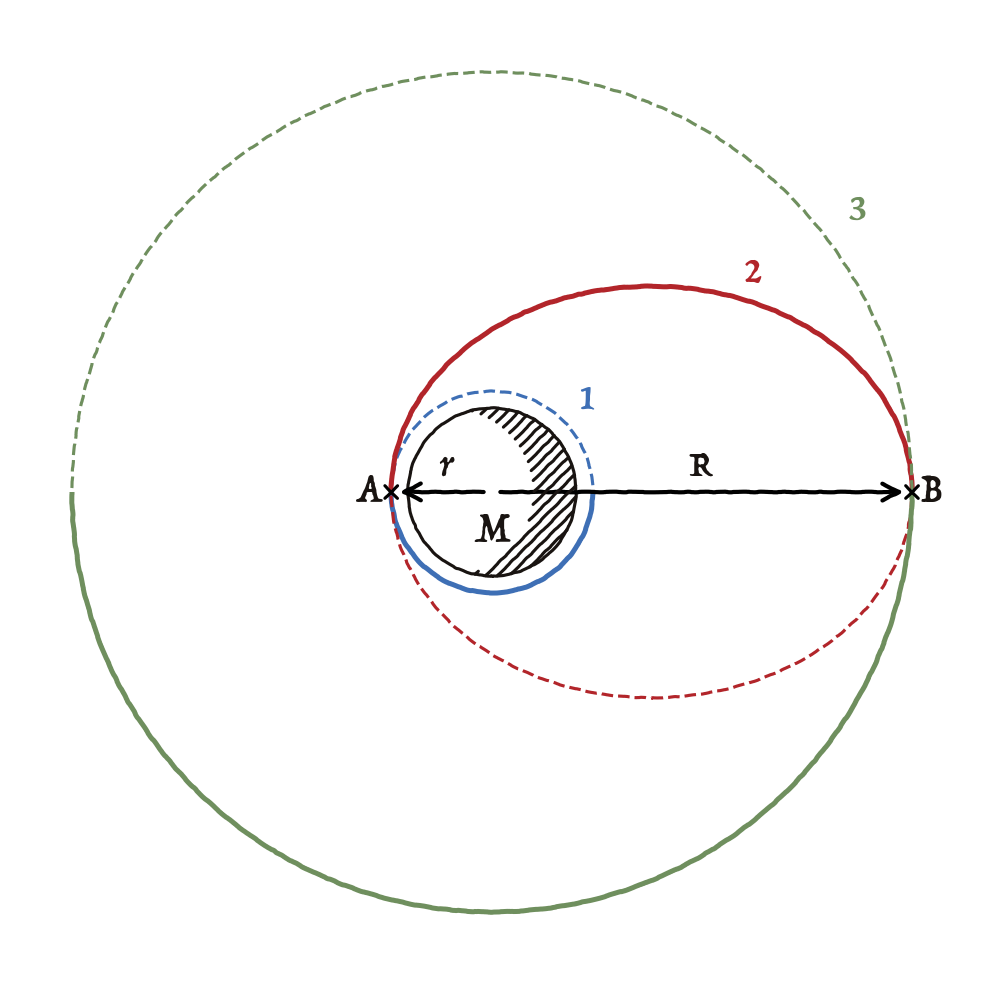

In [5]:
# @title Fig. 1 { vertical-output: true}


class Scratch:
    e = (Parameters.Fig1.R - Parameters.Fig1.r) / (
        Parameters.Fig1.R + Parameters.Fig1.r
    )
    a = (Parameters.Fig1.R + Parameters.Fig1.r) / 2
    b = np.sqrt(Parameters.Fig1.R * Parameters.Fig1.r)


fig = plt.figure(figsize=(4, 4), dpi=300)
ax = fig.add_subplot(111)

myplt.hatchedCircle(
    ax,
    (0, 0),
    Parameters.Fig1.r0,
    shade_from=180,
    shade_depth=0.5,
    spacing=0.1,
    linewidth=0.75,
)
ax.add_artist(
    mpatches.Circle(
        (0, 0),
        Parameters.Fig1.r,
        fill=False,
        color=Parameters.Common.C0,
        linewidth=0.75,
        ls="--",
    )
)
ax.add_artist(
    mpatches.Arc(
        (0, 0),
        Parameters.Fig1.r * 2,
        Parameters.Fig1.r * 2,
        theta1=180,
        theta2=0,
        color=Parameters.Common.C0,
        linewidth=1.2,
        ls="-",
    )
)
ax.add_artist(
    mpatches.Ellipse(
        (
            -Parameters.Fig1.r + (Parameters.Fig1.R + Parameters.Fig1.r) / 2,
            0,
        ),
        Scratch.a * 2,
        Scratch.b * 2,
        fill=False,
        color=Parameters.Common.C1,
        linewidth=0.75,
        ls="--",
    )
)
ax.add_artist(
    mpatches.Arc(
        (
            -Parameters.Fig1.r + (Parameters.Fig1.R + Parameters.Fig1.r) / 2,
            0,
        ),
        Scratch.a * 2,
        Scratch.b * 2,
        theta1=0,
        theta2=180,
        color=Parameters.Common.C1,
        linewidth=1.2,
        ls="-",
    )
)
ax.add_artist(
    mpatches.Circle(
        (0, 0),
        Parameters.Fig1.R,
        fill=False,
        color=Parameters.Common.C2,
        linewidth=0.75,
        ls="--",
    )
)
ax.add_artist(
    mpatches.Arc(
        (0, 0),
        Parameters.Fig1.R * 2,
        Parameters.Fig1.R * 2,
        theta1=180,
        theta2=0,
        color=Parameters.Common.C2,
        linewidth=1.2,
        ls="-",
    )
)

arr_r = mpatches.FancyArrowPatch(
    (0, 0),
    (-Parameters.Fig1.r, 0),
    arrowstyle="->",
    mutation_scale=10,
)
ax.add_artist(arr_r)
ax.annotate("r", (0.5, 0.5), xycoords=arr_r, ha="center", va="bottom")
arr_R = mpatches.FancyArrowPatch(
    (0, 0),
    (Parameters.Fig1.R, 0),
    arrowstyle="->",
    mutation_scale=10,
)
ax.add_artist(arr_R)
ax.annotate("R", (0.5, 0.5), xycoords=arr_R, ha="center", va="bottom")
ax.text(-Parameters.Fig1.r - 0.1, 0, "A", ha="right", va="center", fontsize="large")
ax.text(Parameters.Fig1.R + 0.1, 0, "B", ha="left", va="center", fontsize="large")
xmark(ax, -Parameters.Fig1.r, 0, 0.075, c="k", lw=0.75, ls="-")
xmark(ax, Parameters.Fig1.R, 0, 0.075, c="k", lw=0.75, ls="-")

ax.text(1, 1, "1", c=Parameters.Common.C0)
ax.text(3, 2.5, "2", c=Parameters.Common.C1)
ax.text(4.25, 3.25, "3", c=Parameters.Common.C2)
ax.text(0, -0.1, r"$M$", ha="center", va="top", fontsize="large")

ax.set(xlim=(-5.5, 5.5), ylim=(-5.5, 5.5), aspect=1)
ax.axis("off");

Рис. 1: Схематическая иллюстрация орбит в процессе гомановского манёвра в различных стадиях движения корабля начиная от круговой орбиты радиусом $r$ до круговой орбиты радиусом $R$. Манёвр включает в себя два этапа ускорения в точках $A$ и $B$. Цельными линиями показана последовательность полёта корабля.

Удобно изобразить гомановский манёвр на графике для эффективного потенциала (Рис. 2):

$$
\mathcal{U}(r) = \frac{\mathcal{L}}{2mr^2} - \frac{GMm}{r},
$$

где $\mathcal{L}$ соответствует сохраняющемуся моменту импульса вдоль каждой траектории. Об этом графике можно думать следующим образом: любая траектория вокруг объекта массы $M$ определяется двумя сохраняющимися вдоль траектории величинами (т.н. интегралами движения) -- полной энергией, $\mathcal{E}$, и моментом импульса, $\mathcal{L}$. Значение момента импульса однозначно определяет кривую эффективного потенциала, $\mathcal{U}(r)$, тогда как значение полной энергии определяет по какой траектории вдоль этой кривой движется тело; в точках минимального и максимального удаления, значение потенциала в точности равно значению полной энергии: $\mathcal{U}(r) = \mathcal{U}(R) = \mathcal{E}$. В случае, когда $r=R$, движение происходит по круговой орбите, что соответствует минимально возможной энергии для фиксированного значения $\mathcal{L}$.

Траектории #1, #2 и #3 из Рис. 1 показаны соответствующими цветами на Рис. 2. Таким образом, манёвр включает в себя два этапа изменения энергии, $\Delta\mathcal{E}_A$ и $\Delta\mathcal{E}_B$, в результате чего корабль выходит на круговую орбиту. Заметим, что вне зависимости от деталей манёвра (к примеру, можно сделать то же самое в несколько ускорений), сумма изменения энергий в результате всегда фиксирована: $\Delta\mathcal{E}_A + \Delta\mathcal{E}_B = \mathcal{E}_3 - \mathcal{E}_1$. Отсюда возникает вопрос:

**Можно ли придумать более эффективную траекторию с точки зрения расхода топлива?**

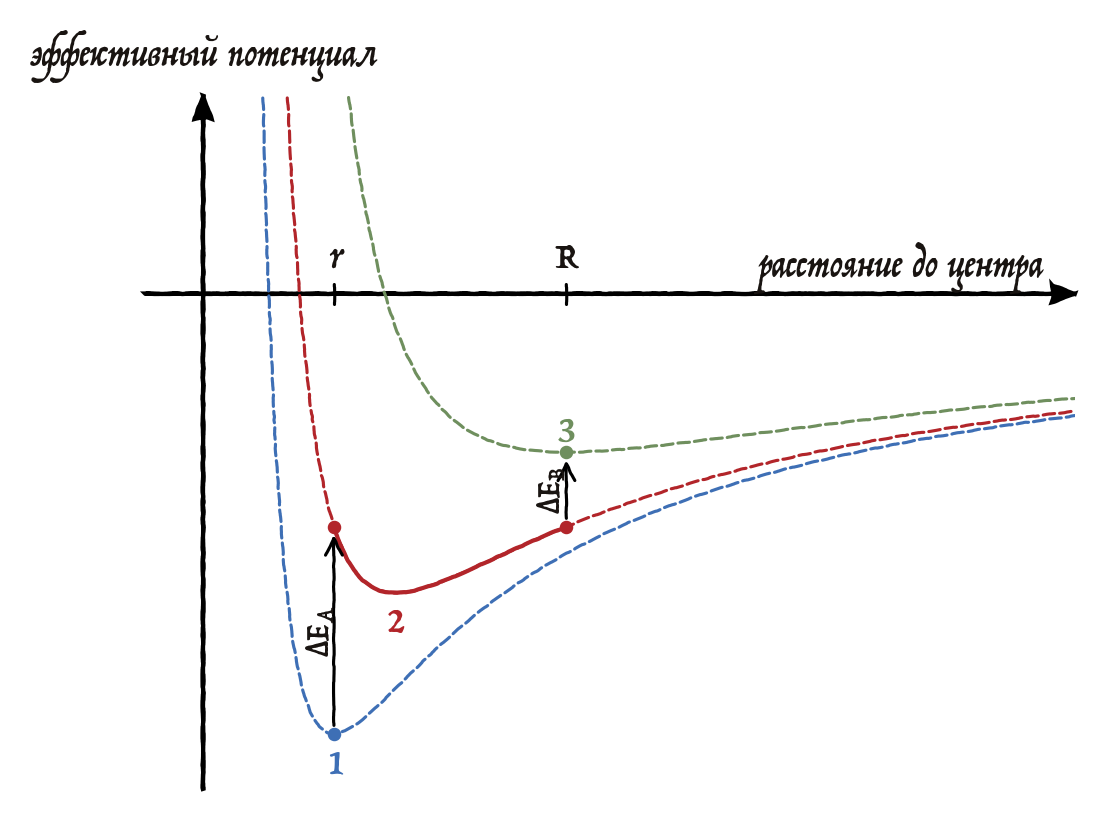

In [6]:
# @title { vertical-output: true}


class Scratch:
    GM = 10
    L1 = 1.5
    L3 = 2.5


r = Scratch.L1**2 / Scratch.GM
R = Scratch.L3**2 / Scratch.GM
L2 = np.sqrt(2 * Scratch.GM / (1 / r + 1 / R))
rm = L2**2 / Scratch.GM


def U1(r):
    return Scratch.L1**2 / (2 * r**2) - Scratch.GM / r


def U2(r):
    return L2**2 / (2 * r**2) - Scratch.GM / r


def U3(r):
    return Scratch.L3**2 / (2 * r**2) - Scratch.GM / r


E1 = U1(r)
E3 = U3(R)


def arrowed_spines(fig, ax):

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # removing the default axis on all sides:
    for side in ["bottom", "right", "top", "left"]:
        ax.spines[side].set_visible(False)

    # removing the axis ticks
    plt.xticks([])  # labels
    plt.yticks([])
    ax.xaxis.set_ticks_position("none")  # tick markers
    ax.yaxis.set_ticks_position("none")

    # get width and height of axes object to compute
    # matching arrowhead length and width
    dps = fig.dpi_scale_trans.inverted()
    bbox = ax.get_window_extent().transformed(dps)
    width, height = bbox.width, bbox.height

    # manual arrowhead width and length
    hw = 1.0 / 40.0 * (ymax - ymin)
    hl = 1.0 / 40.0 * (xmax - xmin)
    lw = 1.0  # axis line width
    ohg = 0.1  # arrow overhang

    # compute matching arrowhead length and width
    yhw = hw / (ymax - ymin) * (xmax - xmin) * height / width
    yhl = hl / (xmax - xmin) * (ymax - ymin) * width / height

    # draw x and y axis
    ax.arrow(
        xmin,
        0,
        xmax - xmin,
        0.0,
        fc="k",
        ec="k",
        lw=lw,
        head_width=hw,
        head_length=hl,
        overhang=ohg,
        length_includes_head=True,
        clip_on=False,
    )

    ax.arrow(
        0,
        ymin,
        0.0,
        ymax - ymin,
        fc="k",
        ec="k",
        lw=lw,
        head_width=yhw,
        head_length=yhl,
        overhang=ohg,
        length_includes_head=True,
        clip_on=False,
    )


rs = np.linspace(0.02, 1.5, 100)

fig = plt.figure(figsize=(4, 3), dpi=300)
ax = fig.add_subplot(111)
ax.plot(rs, U1(rs), c=Parameters.Common.C0, lw=0.75, ls="--")
ax.scatter([r], [E1], c=Parameters.Common.C0, s=5)
ax.text(r, E1 - 0.3, "1", ha="center", va="top", c=Parameters.Common.C0)
ax.plot(rs, U2(rs), c=Parameters.Common.C1, lw=0.75, ls="--")
rr = rs[(r < rs) & (rs <= R)]
ax.plot(rr, U2(rr), c=Parameters.Common.C1, lw=1, ls="-")
ax.text(rm, U2(rm) - 0.3, "2", ha="center", va="top", c=Parameters.Common.C1)
ax.scatter([r, R], [U2(r), U2(R)], c=Parameters.Common.C1, s=5)
ax.plot(rs, U3(rs), c=Parameters.Common.C2, lw=0.75, ls="--")
ax.scatter([R], [U3(R)], c=Parameters.Common.C2, s=5)
ax.text(R, U3(R) - 0.3, "3", ha="center", va="bottom", c=Parameters.Common.C2)
ax.set(xlim=(-0.1, 1.5), ylim=(-25, 10))
ax.annotate(
    "",
    xy=(r, U1(r)),
    xytext=(r, U2(r)),
    arrowprops=dict(arrowstyle="<-", lw=0.75, color="k"),
)
ax.text(
    r + 0.02, (U1(r) + U2(r)) / 2, r"$\Delta E_A$", ha="right", va="center", rotation=90
)
ax.annotate(
    "",
    xy=(R, U2(R)),
    xytext=(R, U3(R)),
    arrowprops=dict(arrowstyle="<-", lw=0.75, color="k"),
)
ax.text(
    R + 0.02, (U2(R) + U3(R)) / 2, r"$\Delta E_B$", ha="right", va="center", rotation=90
)


arrowed_spines(fig, ax)
ax.plot([r, r], [-0.5, 0.5], c="k", lw=0.75)
ax.text(r, 0.5, "r", ha="center", va="bottom")
ax.plot([R, R], [-0.5, 0.5], c="k", lw=0.75)
ax.text(R, 0.5, "R", ha="center", va="bottom")
ax.text(1.2, 0, "расстояние до центра", ha="center", va="bottom")
ax.text(0.0, 12, "эффективный потенциал", ha="center", va="center");

Рис. 2: Эффективный потенциал орбит в зависимости от расстояния до центра для трёх траекторий. Минимумы каждого из потенциалов соответствуют круговым траекториям. Движение по эллиптической траектории соответствует линии вдоль кривой потенциала между ближайшей и самой далёкой точками: $r$ и $R$.

## Подсказка #1

Нужно иметь ввиду, что после каждого этапа манёвра, масса корабля меняется. Согласно формуле Циолковского, изменение скорости корабля напрямую связано с изменением её массы:

$$
\Delta v = v_0 \log{\frac{m+\Delta m}{m}},
$$

где $v_0$ скорость истечения топливо относительно корабля, $\Delta m$, количество израсходованного топлива.

## Подсказка #2

Не смотря на то, что изменение энергии при любом манёвре от круговой орбиты $r$ до $R$ всегда будет одинаково, с точки зрения экономии топлива, нам важно не изменение энергии, а изменение скорости корабля (см. формулу Циолковского).

# Решение

Разберёмся сперва с задачей про гомановский манёвр.

Обозначим за $v_1 \equiv v_\oplus = \sqrt{GM/r}$ и $v_3 = \sqrt{GM/R} = v_\oplus\sqrt{r/R}$ скорости круговых орбит в начальной и финальной стадии.

> Формулу для скорости на круговой траектории можно найти, приравняв центростремительное ускорение $mv^2 / r$ к гравитационной силе притяжения центрального объекта $GMm/r^2$.

Скорости на эллиптической траектории #2, обозначим соответственно $v_{2;r}$ и $v_{2;R}$. Закон сохранения момента импульса на траектории #2 гласит, что

$$
\mathcal{L}_2 = m_2 v_{2;r} r = m_2 v_{2;R} R,
$$

а закон сохранения энергии:

$$
\mathcal{E}_2 = \frac{1}{2}m_2 v_{2;r}^2 - \frac{G M m_2}{r} = \frac{1}{2}m_2 v_{2;R}^2 - \frac{G M m_2}{R},
$$

где $m_2$ -- это масса корабля во время движения по траектории #2.

Формула Циолковского также гласит, что при идеальном манёвре без потерь, изменение массы корабля напрямую связано с изменением скорости движения корабля (в точках $A$ и $B$ соответственно):

$$
\Delta v_A \equiv v_{2;r} - v_1 = v_0\log{\frac{m_2}{m_1}},\\
\Delta v_B \equiv v_3 - v_{2;R} = v_0\log{\frac{m_3}{m_2}}.
$$

Таким образом, мы получаем 4 уравнения с 4 неизвестными -- $v_{2;r}$, $v_{2;R}$, $m_2 / m_1$, $m_3 / m_1$. Решив эту систему и подставив значения для $v_1$ и $v_3$, получим (взяв $x\equiv r/R\leq 1$):

$$
\frac{m_1}{m_3} = \exp{\left[\frac{v_\oplus}{v_0}\left(\sqrt{2}\frac{1-x}{\sqrt{1+x}}+\sqrt{x}-1\right)\right]}.
$$

Для значений $\Delta v$ в точках $A$ и $B$ получим:

$$
\Delta v_A = v_\oplus\left(\frac{\sqrt{2}}{\sqrt{1+x}} - 1\right),\\
\Delta v_B = v_\oplus \left(\sqrt{x}-\frac{\sqrt{2}x}{\sqrt{1+x}}\right).
$$

In [8]:
# @title { vertical-output: true}

v2R, v2r, R, m3, m1, m2, v1, vo, ve, x = sp.symbols(
    r"v_{2;R} v_{2;r} R m_3 m_1 m_2 v_1 v_\oplus v_e x",
    real=True,
    positive=True,
)
r = x * R

GM = r * vo**2
v1 = sp.sqrt(GM / r)
v3 = sp.sqrt(GM / R)

l2_lhs = v2r * r
l2_rhs = v2R * R

e2_lhs = v2r**2 / 2 - GM / r
e2_rhs = v2R**2 / 2 - GM / R

delta_v_A_lhs = v2r - v1
delta_v_A_rhs = ve * sp.log(m1 / m2)

delta_v_B_lhs = v3 - v2R
delta_v_B_rhs = ve * sp.log(m2 / m3)

equations = (
    l2_lhs - l2_rhs,
    e2_lhs - e2_rhs,
    delta_v_A_lhs - delta_v_A_rhs,
    delta_v_B_lhs - delta_v_B_rhs,
)
sol = sp.solve(equations, (m1, m2, v2R, v2r), dict=True)

simplified_m1_ovr_m3 = sp.sqrt(x) + sp.sqrt(2) * (1 - x) / sp.sqrt(1 + x) - 1

assert ((sp.log(sol[0][m1] / m3) * ve / vo) - simplified_m1_ovr_m3).simplify() == 0, (
    "failed"
)

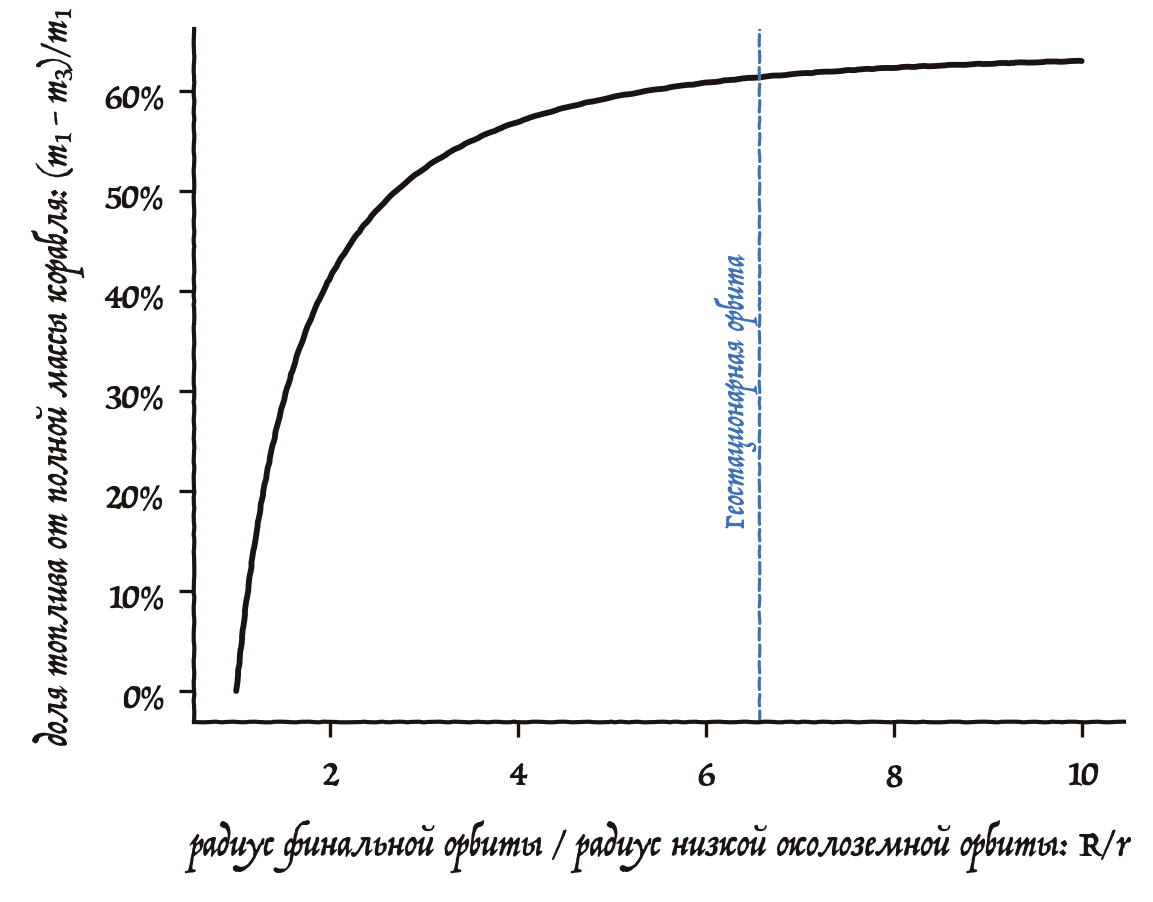

In [9]:
# @title { vertical-output: true}

log_m1_ovr_m3 = sp.lambdify(x, sp.log(sol[0][m1] / m3) * ve / vo, modules=["numpy"])

fig = plt.figure(figsize=(4, 3), dpi=300)
ax = fig.add_subplot(111)


def func(R_ovr_r, vplus_ovr_v0):
    m1_ovr_m3 = np.exp(vplus_ovr_v0 * log_m1_ovr_m3(1 / R_ovr_r))
    return (m1_ovr_m3 - 1) / m1_ovr_m3


R_ovr_r = np.linspace(1, 10, 100)
ax.plot(R_ovr_r, func(R_ovr_r, 7.5 / 4) * 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.axvline(x=42000 / 6400, color=Parameters.Common.C0, ls="--", lw=0.75)
ax.text(
    42000 / 6400,
    30,
    "Геостационарная орбита",
    rotation=90,
    va="center",
    ha="right",
    fontsize="small",
    c=Parameters.Common.C0,
)
ax.set(
    xlabel="радиус финальной орбиты / радиус низкой околоземной орбиты: R/r",
    ylabel="доля топлива от полной массы корабля: $(m_1-m_3)/m_1$",
);